System : Lorenz attractor  ẋ=σ(y-x), ẏ=x(ρ-z)-y, ż=xy-βz
Dim    : 3   Vars: ['x', 'y', 'z']

Data shape : (2000, 3)   t ∈ [0.00, 19.99]
Noise level: 0.0


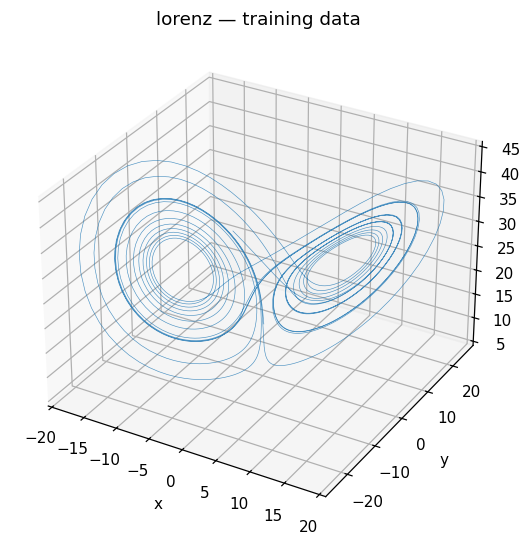

Library: polynomial (degree 2).

Fit time : 0.221 s

Discovered equations:
(x)' = -10.000 x +  10.000 y
(y)' =  28.002 x + -1.001 y + -1.000 x z
(z)' = -2.667 z +  1.000 x y


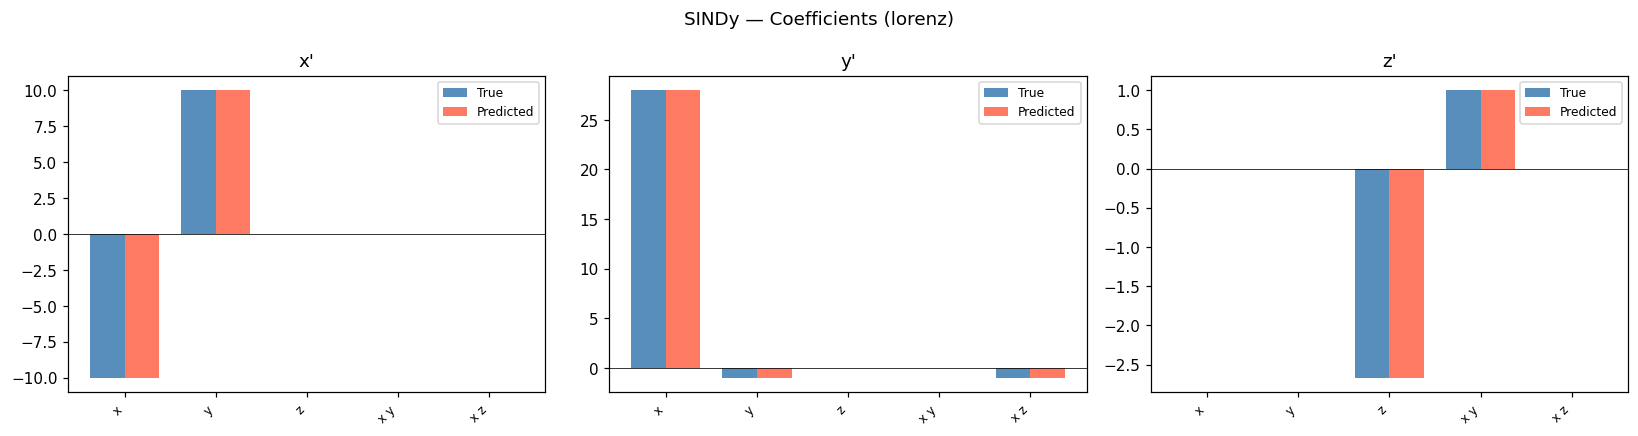

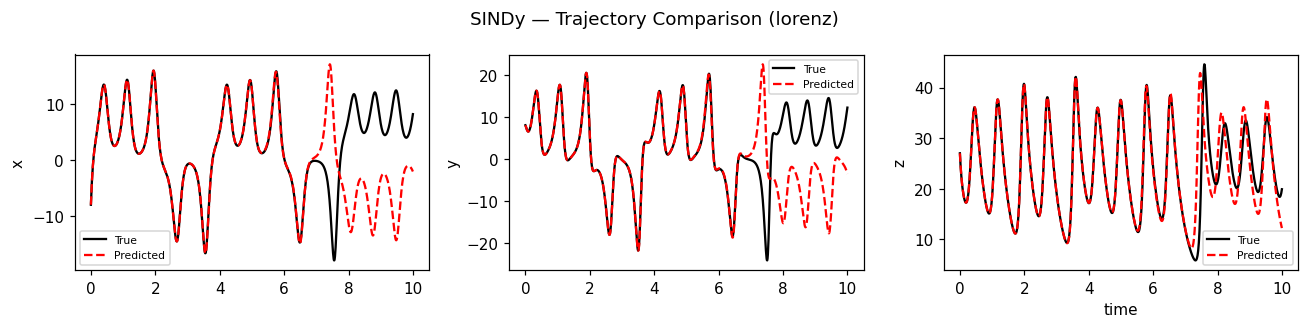


  SINDy
  Traj. L2 error [x]  : 1.0725
  Traj. L2 error [y]  : 1.0341
  Traj. L2 error [z]  : 0.1669
  Total traj. L2 error    : 0.4777
  Coefficient L2 error    : 0.0001
  Precision               : 1.000
  Recall                  : 1.000
  Fit time : 0.221 s

Results saved → results/sindy_lorenz_results.pkl
  noise=0.00  traj_err=0.4777  coef_err=8.124610998279392e-05
  noise=0.01  traj_err=0.4246  coef_err=0.006613083248278429
  noise=0.05  traj_err=0.7425  coef_err=0.2980271472955982
  noise=0.10  traj_err=0.6896  coef_err=0.5885964504937481
  noise=0.20  traj_err=23.1972  coef_err=4626949464.625387


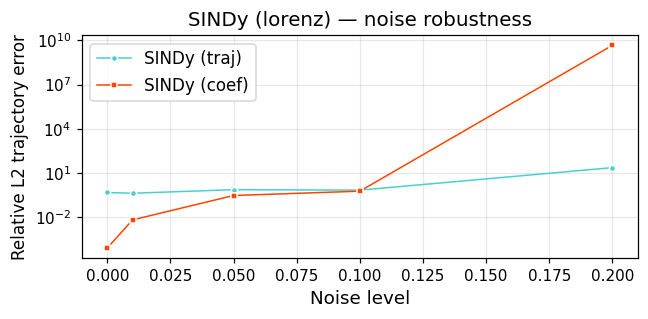

In [3]:
# =============================================================================
# 01_SINDy.py
# Standard SINDy (PySINDy / STLSQ) on any registered ODESystem.
# =============================================================================

# %% ── USER PARAMETERS ────────────────────────────────────────────────────────

import sys, os
sys.path.insert(0, os.getcwd())
from ode_systems import SYSTEMS, list_systems

# System selection — change this key to switch problems.
# Run list_systems() to see all available options.
SYSTEM_KEY = "lorenz"
SYSTEM     = SYSTEMS[SYSTEM_KEY]

# Initial condition (must have SYSTEM.n_dim entries)
X0 = [-8.0, 8.0, 27.0]

# Integration
T_SPAN      = (0.0, 20.0)   # (t_start, t_end)
DT          = 0.01           # timestep
NOISE_LEVEL = 0.00           # additive noise as fraction of signal RMS
SEED        = 42

# Candidate library
POLY_DEGREE       = 2        # polynomial degree
INCLUDE_SINE      = False    # add Fourier terms (useful for oscillators)
CUSTOM_LIBRARY_FN = None     # set to a callable () -> PySINDy library, or None

# Optimiser (STLSQ)
THRESHOLD = 0.05   # sparsity threshold
ALPHA     = 0.05   # ridge regularisation
MAX_ITER  = 20

# Differentiation
# Options: 'spline' | 'smoothed_finite_difference' | 'finite_difference'
DIFF_METHOD = "spline"
SPLINE_S    = 1e-3   # smoothing factor (spline only)

# Evaluation
T_EVAL_END         = 10.0   # trajectory comparison window
SWEEP_NOISE_LEVELS = [0.0, 0.01, 0.05, 0.1, 0.2]

RESULTS_FILE = f"results/sindy_{SYSTEM_KEY}_results.pkl"

# %% ── IMPORTS ─────────────────────────────────────────────────────────────────

import pickle, time, warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib; matplotlib.rcParams["figure.dpi"] = 110

import pysindy as ps
from pysindy.differentiation import (SINDyDerivative,
                                      SmoothedFiniteDifference,
                                      FiniteDifference)
from pysindy.feature_library import FourierLibrary, ConcatLibrary

from ode_utils import (
    generate_data, simulate_from_coefficients,
    plot_phase_portrait, plot_trajectories, plot_coefficient_comparison,
    plot_noise_sweep, relative_l2_error, coefficient_error, precision_recall,
    print_metrics, metrics_dict, build_true_coef_matrix,
    print_discovered_equations,
)

os.makedirs("results", exist_ok=True)
print(f"System : {SYSTEM.description}")
print(f"Dim    : {SYSTEM.n_dim}   Vars: {SYSTEM.var_names}")

# %% ── 1. GENERATE DATA ────────────────────────────────────────────────────────

t, X = generate_data(SYSTEM, X0, T_SPAN, DT,
                     noise_level=NOISE_LEVEL, seed=SEED)
print(f"\nData shape : {X.shape}   t ∈ [{t[0]:.2f}, {t[-1]:.2f}]")
print(f"Noise level: {NOISE_LEVEL}")

fig = plot_phase_portrait(t, X, SYSTEM.var_names,
                           title=f"{SYSTEM_KEY} — training data")
plt.tight_layout()
plt.savefig(f"results/sindy_{SYSTEM_KEY}_phase.png", dpi=150, facecolor="none", transparent= True)
plt.show()

# %% ── 2. BUILD LIBRARY & DIFFERENTIATOR ──────────────────────────────────────

if DIFF_METHOD == "spline":
    diff = SINDyDerivative(kind="spline", s=SPLINE_S)
elif DIFF_METHOD == "smoothed_finite_difference":
    diff = SmoothedFiniteDifference()
else:
    diff = FiniteDifference()

if SYSTEM.custom_library is not None:
    library = SYSTEM.custom_library.to_pysindy_library()
    print(f"Library: custom ({SYSTEM.custom_library.names}).")
elif CUSTOM_LIBRARY_FN is not None:
    library = CUSTOM_LIBRARY_FN()
    print("Using custom library.")
elif INCLUDE_SINE:
    library = ConcatLibrary([
        ps.PolynomialLibrary(degree=POLY_DEGREE),
        FourierLibrary(n_frequencies=1),
    ])
    print(f"Library: polynomial (deg {POLY_DEGREE}) + Fourier.")
else:
    library = ps.PolynomialLibrary(degree=POLY_DEGREE)
    print(f"Library: polynomial (degree {POLY_DEGREE}).")

# %% ── 3. FIT ──────────────────────────────────────────────────────────────────

optimizer = ps.STLSQ(threshold=THRESHOLD, alpha=ALPHA, max_iter=MAX_ITER)

model = ps.SINDy(
    feature_library=library,
    optimizer=optimizer,
    differentiation_method=diff,
)

t0 = time.time()
model.fit(X, t=DT, feature_names=SYSTEM.var_names)
fit_time = time.time() - t0

print(f"\nFit time : {fit_time:.3f} s")
print("\nDiscovered equations:")
model.print()

feature_names = model.get_feature_names()
coef          = model.coefficients()   # (n_eqs, n_features)

# %% ── 4. COEFFICIENT COMPARISON ──────────────────────────────────────────────

true_coef = build_true_coef_matrix(SYSTEM, feature_names)

if true_coef is not None:
    active = np.where(
        np.any(np.abs(true_coef) > 1e-4, axis=0) |
        np.any(np.abs(coef)      > 1e-4, axis=0)
    )[0]
    dot_names = [f"{v}'" for v in SYSTEM.var_names]
    fig = plot_coefficient_comparison(
        true_coef[:, active], coef[:, active],
        [feature_names[i] for i in active],
        eq_names=dot_names,
        title=f"SINDy — Coefficients ({SYSTEM_KEY})",
    )
    plt.tight_layout()
    plt.savefig(f"results/sindy_{SYSTEM_KEY}_coefficients.png", dpi=150, facecolor="none", transparent= True)
    plt.show()
else:
    print_discovered_equations(coef, feature_names, SYSTEM.var_names)

# %% ── 5. SIMULATE & COMPARE ──────────────────────────────────────────────────

t_test      = t[t <= T_EVAL_END]
X_true_test = X[:len(t_test)]

try:
    X_pred = model.simulate(X0, t=t_test)
    sim_ok = True
except Exception as e:
    print(f"Simulation failed: {e}")
    X_pred = np.full_like(X_true_test, np.nan)
    sim_ok = False

if sim_ok:
    fig = plot_trajectories(
        t_test, X_true_test, X_pred, SYSTEM.var_names,
        title=f"SINDy — Trajectory Comparison ({SYSTEM_KEY})",
    )
    plt.savefig(f"results/sindy_{SYSTEM_KEY}_trajectory.png", dpi=150, facecolor="none", transparent= True)
    plt.show()

# %% ── 6. METRICS & SAVE ───────────────────────────────────────────────────────

per_dim, total = relative_l2_error(X_true_test, X_pred)
coef_err  = (coefficient_error(true_coef.flatten(), coef.flatten())
             if true_coef is not None else None)
prec, rec = (precision_recall(true_coef.flatten(), coef.flatten())
             if true_coef is not None else (None, None))

print_metrics("SINDy", per_dim, total, coef_err, prec, rec,
              var_names=SYSTEM.var_names)
print(f"  Fit time : {fit_time:.3f} s")

results = dict(
    system_key=SYSTEM_KEY,
    coef=coef,
    true_coef=true_coef,
    feature_names=feature_names,
    var_names=SYSTEM.var_names,
    **metrics_dict("SINDy", per_dim, total, coef_err, prec, rec, fit_time),
    t_test=t_test,
    X_true=X_true_test,
    X_pred=X_pred,
    params=dict(threshold=THRESHOLD, alpha=ALPHA, poly_degree=POLY_DEGREE,
                diff_method=DIFF_METHOD, noise_level=NOISE_LEVEL),
)
with open(RESULTS_FILE, "wb") as fh:
    pickle.dump(results, fh)
print(f"\nResults saved → {RESULTS_FILE}")

# %% ── 7. NOISE SWEEP ─────────────────────────────────────────────────────────

traj_errs, coef_errs = [], []

for nl in SWEEP_NOISE_LEVELS:
    _, Xn = generate_data(SYSTEM, X0, T_SPAN, DT, noise_level=nl, seed=SEED)
    m = ps.SINDy(
        feature_library=library,
        optimizer=ps.STLSQ(threshold=THRESHOLD, alpha=ALPHA, max_iter=MAX_ITER),
        differentiation_method=diff,
    )
    m.fit(Xn, t=DT, feature_names=SYSTEM.var_names)
    try:
        Xp = m.simulate(X0, t=t_test)
        _, te = relative_l2_error(X_true_test, Xp)
    except Exception:
        te = np.nan
    ce = (coefficient_error(true_coef.flatten(), m.coefficients().flatten())
          if true_coef is not None else np.nan)
    traj_errs.append(te)
    coef_errs.append(ce)
    print(f"  noise={nl:.2f}  traj_err={te:.4f}  coef_err={ce}")

fig = plot_noise_sweep(SWEEP_NOISE_LEVELS,
                       {"SINDy (traj)": traj_errs, "SINDy (coef)": coef_errs},
                       metric="traj",
                       title=f"SINDy ({SYSTEM_KEY}) — noise robustness")
plt.savefig(f"results/sindy_{SYSTEM_KEY}_noise_sweep.png", dpi=150, facecolor="none", transparent= True)
plt.show()